In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import IsolationForest

In [28]:
df = pd.read_csv('D:/bachelor-thesis/resources/clean.csv')
df = df.drop(columns=['Source'])

In [13]:
print(df.columns)

Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Total Length of Fwd Packets',
       'Total Length of Bwd Packets', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Min Packet Length', 'Max Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'R

In [8]:
print("=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Data Types ===")
print(df.dtypes)
print("\n=== Duplicated Rows ===")
print(f"Total duplicate rows: {df.duplicated().sum()}")

=== Missing Values ===
Protocol                       0
Flow Duration                  0
Total Fwd Packets              0
Total Backward Packets         0
Total Length of Fwd Packets    0
                              ..
Idle Mean                      0
Idle Std                       0
Idle Max                       0
Idle Min                       0
Attack                         0
Length: 79, dtype: int64

=== Data Types ===
Protocol                         int64
Flow Duration                    int64
Total Fwd Packets                int64
Total Backward Packets           int64
Total Length of Fwd Packets      int64
                                ...   
Idle Mean                      float64
Idle Std                       float64
Idle Max                       float64
Idle Min                       float64
Attack                           int64
Length: 79, dtype: object

=== Duplicated Rows ===
Total duplicate rows: 174151


In [15]:
if 'Attack' in df.columns:
    print("\n=== Attack Label Distribution ===")
    print(df['Attack'].value_counts(normalize=True))


=== Attack Label Distribution ===
Attack
1    0.560231
0    0.439769
Name: proportion, dtype: float64


In [16]:
def detect_outliers(col, z_thresh=3):
    if col in df.columns:
        z_scores = (df[col] - df[col].mean()) / df[col].std()
        return (np.abs(z_scores) > z_thresh).sum()
    return 0

print("\n=== Outlier Count (Z > 3) for Key Metrics ===")
for feature in ['Flow Duration', 'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packet Length Mean', 'Bwd Packet Length Mean']:
    print(f"{feature}: {detect_outliers(feature)}")


=== Outlier Count (Z > 3) for Key Metrics ===
Flow Duration: 21974
Flow Bytes/s: 511
Flow Packets/s: 9477
Fwd Packet Length Mean: 18106
Bwd Packet Length Mean: 318


In [18]:
print("\n=== Derived Feature Consistency Checks ===")

# Flow Bytes/s check
if {'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Flow Duration', 'Flow Bytes/s'}.issubset(df.columns):
    df['Calc Flow Bytes/s'] = (df['Total Length of Fwd Packets'] + df['Total Length of Bwd Packets']) / df['Flow Duration'].replace(0, np.nan)
    corr_bytes = df[['Flow Bytes/s', 'Calc Flow Bytes/s']].corr().iloc[0,1]
    print(f"Correlation (Flow Bytes/s vs calculated): {corr_bytes:.3f}")

# Avg Fwd Segment Size ≈ Total Fwd Bytes / Total Fwd Packets
if {'Total Length of Fwd Packets', 'Total Fwd Packets', 'Avg Fwd Segment Size'}.issubset(df.columns):
    df['Calc Avg Fwd Segment Size'] = df['Total Length of Fwd Packets'] / df['Total Fwd Packets'].replace(0, np.nan)
    corr_fwd_seg = df[['Avg Fwd Segment Size', 'Calc Avg Fwd Segment Size']].corr().iloc[0,1]
    print(f"Correlation (Avg Fwd Segment Size vs calculated): {corr_fwd_seg:.3f}")


=== Derived Feature Consistency Checks ===
Correlation (Flow Bytes/s vs calculated): 1.000
Correlation (Avg Fwd Segment Size vs calculated): 1.000


In [21]:
from scipy.stats import zscore

df_cleaned = df.copy()

# Define columns to clean
columns_to_check = ['Flow Duration', 'Flow Bytes/s', 'Flow Packets/s', 
                    'Fwd Packet Length Mean', 'Bwd Packet Length Mean']

# Filter out rows where any of these features are Z > 3
z_scores = np.abs(df_cleaned[columns_to_check].apply(zscore))
df_no_outliers = df_cleaned[(z_scores < 3).all(axis=1)]

# Check how the label distribution changes
print("Original Attack Distribution:")
print(df['Attack'].value_counts(normalize=True))

print("\nAfter Removing Outliers:")
print(df_no_outliers['Attack'].value_counts(normalize=True))

print(f"\nRemoved {len(df) - len(df_no_outliers)} rows ({(1 - len(df_no_outliers)/len(df)) * 100:.2f}%)")

Original Attack Distribution:
Attack
1    0.560231
0    0.439769
Name: proportion, dtype: float64

After Removing Outliers:
Attack
1    0.599825
0    0.400175
Name: proportion, dtype: float64

Removed 47178 rows (9.21%)


The removed outliers were disproportionately normal flows, causing a ~4% increase in the attack rate. While not catastrophic, this suggests outliers contain some valid non-attack diversity, and trimming them may bias your model. It's best to try training both with and without them to compare impact.

In [22]:
df[numeric_cols := df.select_dtypes(include='number').columns].std().sort_values(ascending=False).head(15)

Flow Duration    2.712714e+07
Fwd IAT Total    2.704408e+07
Flow Bytes/s     2.222931e+07
Bwd IAT Total    2.159339e+07
Fwd IAT Max      2.023747e+07
Idle Max         1.986544e+07
Flow IAT Max     1.983521e+07
Idle Mean        1.647327e+07
Idle Min         1.496171e+07
Bwd IAT Max      1.265023e+07
Idle Std         8.698206e+06
Fwd IAT Std      7.771771e+06
Flow IAT Std     6.080575e+06
Fwd IAT Mean     6.023558e+06
Bwd IAT Mean     5.574226e+06
dtype: float64

In [23]:
df.corr()['Attack'].abs().sort_values(ascending=False).head(15)

Attack                       1.000000
Protocol                     0.530816
PSH Flag Count               0.524551
Min Packet Length            0.495426
Bwd Packet Length Min        0.409287
URG Flag Count               0.348353
Bwd Packet Length Std        0.317663
Bwd Packet Length Max        0.302092
Bwd Packet Length Mean       0.301069
Avg Bwd Segment Size         0.301069
Bwd IAT Total                0.283798
Calc Avg Fwd Segment Size    0.267357
Fwd Packet Length Mean       0.267357
Avg Fwd Segment Size         0.267357
Fwd Packet Length Max        0.242513
Name: Attack, dtype: float64

In [24]:
from scipy.stats import ks_2samp

results = {}
for col in ['Flow Duration', 'Flow Bytes/s', 'Flow Packets/s', 'Fwd Packet Length Mean', 'Bwd Packet Length Mean']:
    a = df[df['Attack'] == 0][col].dropna()
    b = df[df['Attack'] == 1][col].dropna()
    stat, p = ks_2samp(a, b)
    results[col] = {'KS_stat': stat, 'p_value': p}

pd.DataFrame(results).T.sort_values('KS_stat', ascending=False)

,KS_stat,p_value
Fwd Packet Length Mean,0.726933,0.0
Flow Duration,0.417347,0.0
Bwd Packet Length Mean,0.385343,0.0
Flow Packets/s,0.375565,0.0
Flow Bytes/s,0.320759,0.0


To guide the modeling process, we selected five key features based on a combination of statistical dispersion, class separability, and domain relevance. These include Flow Duration, Flow Bytes/s, Flow Packets/s, Fwd Packet Length Mean, and Bwd Packet Length Mean. Variance analysis revealed that Flow Duration and Flow Bytes/s exhibit among the highest variability in the dataset, suggesting their importance in modeling diverse flow behaviors. While correlation with the Attack label varied, Kolmogorov–Smirnov tests confirmed that all five features exhibit statistically significant distribution differences across attack and non-attack classes (p < 0.001), with Fwd Packet Length Mean showing particularly strong class separability (KS=0.727). These features collectively span temporal, volumetric, and structural aspects of network flows, making them well-suited for training generative models like GANs.

# Onto the synthetic dataset analysis and evaluation...

In [27]:
synth_df = pd.read_csv('D:/bachelor-thesis/resources/initSynthData.csv')

In [29]:
real = df.drop(columns=['Attack'])
synthetic = synth_df.drop(columns=['Attack'])

In [34]:
top_features = [
    'Fwd Packet Length Mean',
    'Flow Duration',
    'Bwd Packet Length Mean',
    'Flow Packets/s',
    'Flow Bytes/s',
    'Bwd Packet Length Std',
    'Min Packet Length',
    'Avg Bwd Segment Size',
    'Avg Fwd Segment Size',
    'Bwd IAT Mean',
    'Fwd IAT Mean',
    'Flow IAT Std',
    'Protocol',
    'PSH Flag Count',
    'URG Flag Count'
]

ks_results_top = {}
for col in top_features:
    stat, p = ks_2samp(df[col].dropna(), synth_df[col].dropna())
    ks_results_top[col] = {'KS_stat': stat, 'p_value': p}

ks_df_top = pd.DataFrame(ks_results_top).T.sort_values('KS_stat', ascending=False)
print("=== KS Test Results on Selected Features ===")
print(ks_df_top)

=== KS Test Results on Selected Features ===
                         KS_stat        p_value
Bwd Packet Length Std   0.631466   0.000000e+00
Bwd IAT Mean            0.627678   0.000000e+00
Flow Packets/s          0.436864   0.000000e+00
Flow Bytes/s            0.390627   0.000000e+00
Avg Bwd Segment Size    0.298549   0.000000e+00
Flow Duration           0.282267   0.000000e+00
Bwd Packet Length Mean  0.232461   0.000000e+00
Fwd Packet Length Mean  0.226937   0.000000e+00
Avg Fwd Segment Size    0.194338   0.000000e+00
Fwd IAT Mean            0.134313   0.000000e+00
Flow IAT Std            0.082455   0.000000e+00
PSH Flag Count          0.075080   0.000000e+00
URG Flag Count          0.048717   0.000000e+00
Min Packet Length       0.029367  2.683824e-169
Protocol                0.012446   9.372724e-31


While most core features were modeled reasonably well by the GAN (KS < 0.3), rate-based and higher-order statistical features—particularly Bwd Packet Length Std and Bwd IAT Mean—showed substantial divergence (KS > 0.6). This suggests that the generative model struggled to capture the variability in backward flow behavior, likely due to outliers or complex distribution shapes. Future retraining iterations may benefit from clipping extreme values or applying log transforms to improve fidelity in these dimensions.

In [31]:
# --- Mean and Std Deviation Comparison ---
summary_df = pd.DataFrame({
    'Real_Mean': real.mean(),
    'Synth_Mean': synthetic.mean(),
    'Real_Std': real.std(),
    'Synth_Std': synthetic.std()
})
summary_df['Mean_Diff'] = abs(summary_df['Real_Mean'] - summary_df['Synth_Mean'])
summary_df['Std_Diff'] = abs(summary_df['Real_Std'] - summary_df['Synth_Std'])

print("\n=== Mean and Std Differences ===")
print(summary_df.sort_values('Mean_Diff', ascending=False).head(10))


=== Mean and Std Differences ===
                  Real_Mean    Synth_Mean      Real_Std     Synth_Std  \
Flow Duration  1.016663e+07  1.377863e+07  2.712714e+07  3.126587e+07   
Fwd IAT Total  9.724758e+06  1.254874e+07  2.704408e+07  3.027148e+07   
Fwd IAT Max    6.718783e+06  9.334507e+06  2.023747e+07  2.396018e+07   
Flow IAT Max   6.963890e+06  8.649741e+06  1.983521e+07  2.143826e+07   
Bwd IAT Total  5.671966e+06  7.265367e+06  2.159339e+07  2.429194e+07   
Bwd IAT Max    2.890904e+06  4.407890e+06  1.265023e+07  1.599923e+07   
Idle Mean      5.445735e+06  6.762465e+06  1.647327e+07  1.837914e+07   
Idle Max       6.596952e+06  7.489878e+06  1.986544e+07  2.046370e+07   
Idle Min       4.277190e+06  5.122455e+06  1.496171e+07  1.651902e+07   
Idle Std       1.626106e+06  2.060278e+06  8.698206e+06  9.345771e+06   

                  Mean_Diff      Std_Diff  
Flow Duration  3.611996e+06  4.138734e+06  
Fwd IAT Total  2.823979e+06  3.227393e+06  
Fwd IAT Max    2.615724e+06  3

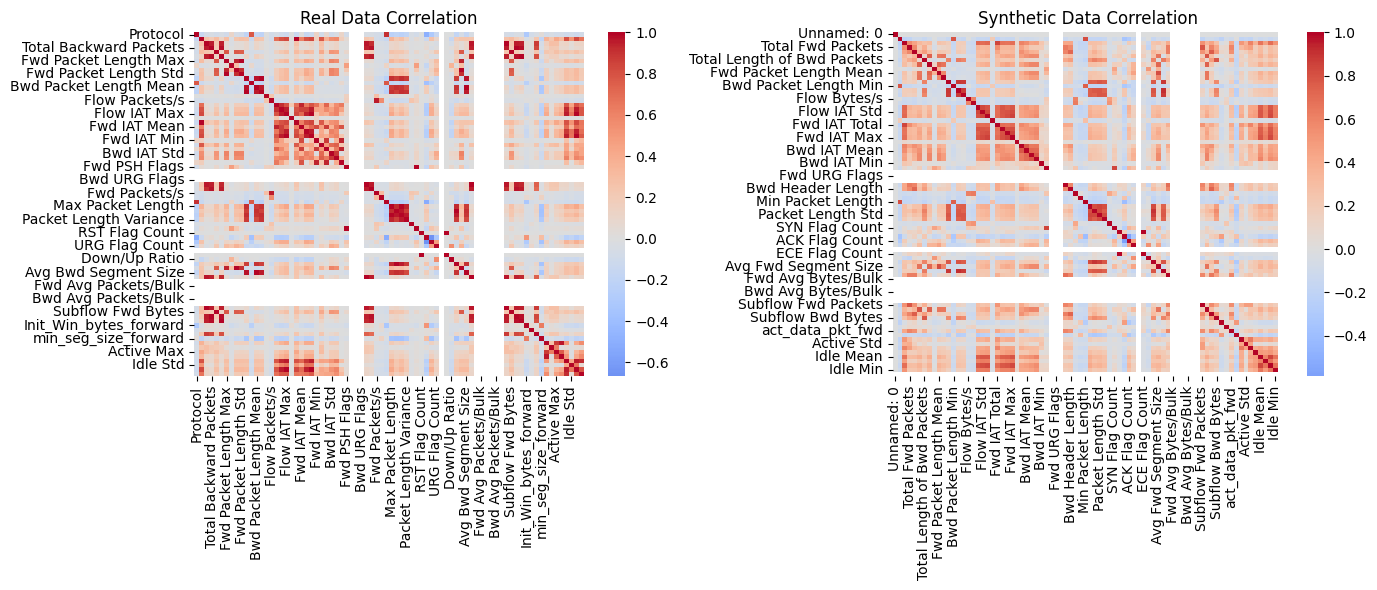

In [33]:
import seaborn as sns

# --- Correlation Heatmap Comparison ---
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.heatmap(real.corr(), cmap='coolwarm', center=0)
plt.title("Real Data Correlation")

plt.subplot(1, 2, 2)
sns.heatmap(synthetic.corr(), cmap='coolwarm', center=0)
plt.title("Synthetic Data Correlation")

plt.tight_layout()
plt.show()

In [36]:
print(f"Unique real rows: {len(df.drop_duplicates())} / {len(df)}")
print(f"Unique synthetic rows: {len(synth_df.drop_duplicates())} / {len(synth_df)}")

Unique real rows: 338061 / 512212
Unique synthetic rows: 402473 / 402473


In [39]:
print("NaNs in real data:", df.isnull().sum().sum())
print("NaNs in synthetic data:", synth_df.isnull().sum().sum())

print("Infs in real data:", np.isinf(df.select_dtypes(include='number')).sum().sum())
print("Infs in synthetic data:", np.isinf(synth_df.select_dtypes(include='number')).sum().sum())

NaNs in real data: 0
NaNs in synthetic data: 0
Infs in real data: 0
Infs in synthetic data: 0


In [40]:
print("Zero duration rows in synthetic data:", (synth_df['Flow Duration'] == 0).sum())

Zero duration rows in synthetic data: 3


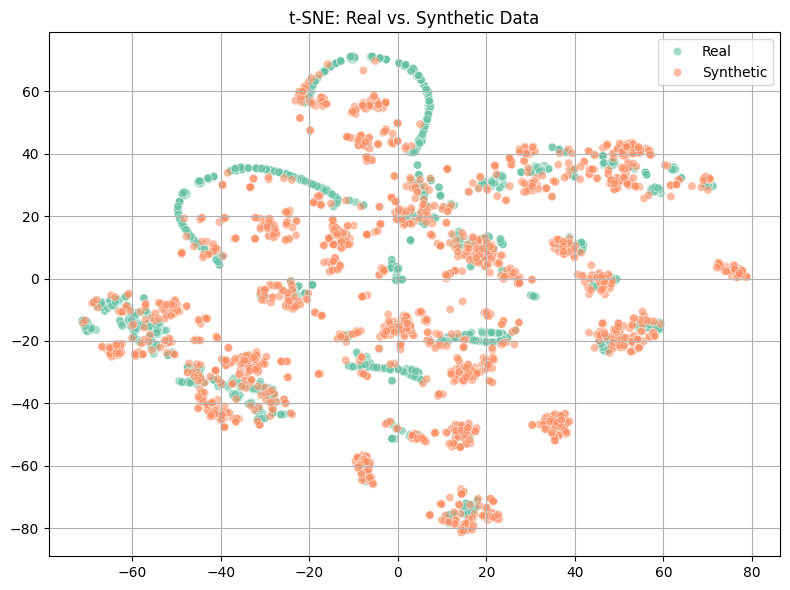

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# --- STEP 1: Prep numeric data ---
X_real = df.drop(columns=['Attack'], errors='ignore').select_dtypes(include='number')
X_synth = synth_df.drop(columns=['Attack'], errors='ignore').select_dtypes(include='number')

# Remove zero-duration synthetic rows
if 'Flow Duration' in X_synth.columns:
    X_synth = X_synth[X_synth['Flow Duration'] > 0]

# Add row identifiers to align labels later
X_real['__index'] = range(len(X_real))
X_synth['__index'] = range(len(X_synth))

# Create label array BEFORE coercion
labels_real = ['Real'] * len(X_real)
labels_synth = ['Synthetic'] * len(X_synth)
labels = pd.Series(labels_real + labels_synth)

# Combine datasets
X_combined = pd.concat([X_real, X_synth], ignore_index=True)
X_combined = X_combined.drop(columns=['__index'], errors='ignore')

# --- STEP 2: Clean & Impute ---
X_combined = X_combined.apply(pd.to_numeric, errors='coerce')
X_combined = X_combined.replace([np.inf, -np.inf], np.nan)

# Impute missing values with column means
imputer = SimpleImputer(strategy='mean')
X_imputed = pd.DataFrame(imputer.fit_transform(X_combined), columns=X_combined.columns)

# --- STEP 3: Split + Sample ---
X_real_clean = X_imputed[labels == 'Real']
X_synth_clean = X_imputed[labels == 'Synthetic']

sample_n = min(2000, len(X_real_clean), len(X_synth_clean))
X_real_sample = X_real_clean.sample(n=sample_n, random_state=42)
X_synth_sample = X_synth_clean.sample(n=sample_n, random_state=42)

X_final = pd.concat([X_real_sample, X_synth_sample], ignore_index=True)
final_labels = ['Real'] * sample_n + ['Synthetic'] * sample_n

# --- STEP 4: t-SNE & Plot ---
X_scaled = StandardScaler().fit_transform(X_final)

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
X_embedded = tsne.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_embedded[:, 0], y=X_embedded[:, 1], hue=final_labels, alpha=0.6, palette='Set2')
plt.title('t-SNE: Real vs. Synthetic Data')
plt.grid(True)
plt.tight_layout()
plt.show()


A t-SNE projection was used to visually compare real and synthetic data distributions. The resulting plot (Fig. X) shows that while many synthetic samples cluster near real samples, indicating successful pattern learning, there are also noticeable regions of divergence. This suggests that the GAN partially captured the true distribution but may have missed or over-represented certain modes, consistent with mild mode collapse. The overlap, however, supports the claim that CTGAN was able to learn core structural patterns from the firewall log data.

In [47]:
def plot_all_kde(real_df, synth_df, features=None, cols_per_fig=6):
    if features is None:
        features = real_df.select_dtypes(include='number').columns.tolist()

    for i in range(0, len(features), cols_per_fig):
        sub_features = features[i:i + cols_per_fig]
        fig, axes = plt.subplots(nrows=1, ncols=len(sub_features), figsize=(4*len(sub_features), 4))
        if len(sub_features) == 1:
            axes = [axes]
        for ax, col in zip(axes, sub_features):
            try:
                real_df[col].plot(kind='kde', ax=ax, label='Real', linewidth=2)
                synth_df[col].plot(kind='kde', ax=ax, label='Synthetic', linestyle='--', linewidth=2)
                ax.set_title(col)
                ax.legend()
            except Exception as e:
                ax.set_title(f"{col} (error)")
                print(f"Could not plot {col}: {e}")
        plt.tight_layout()
        plt.show()

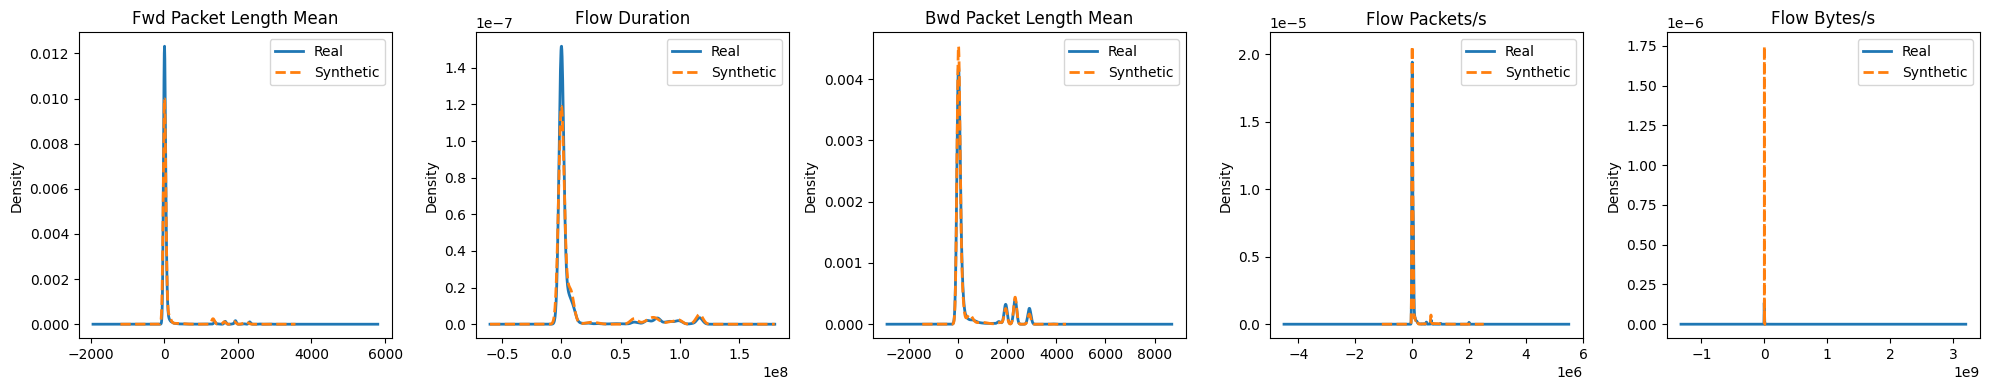

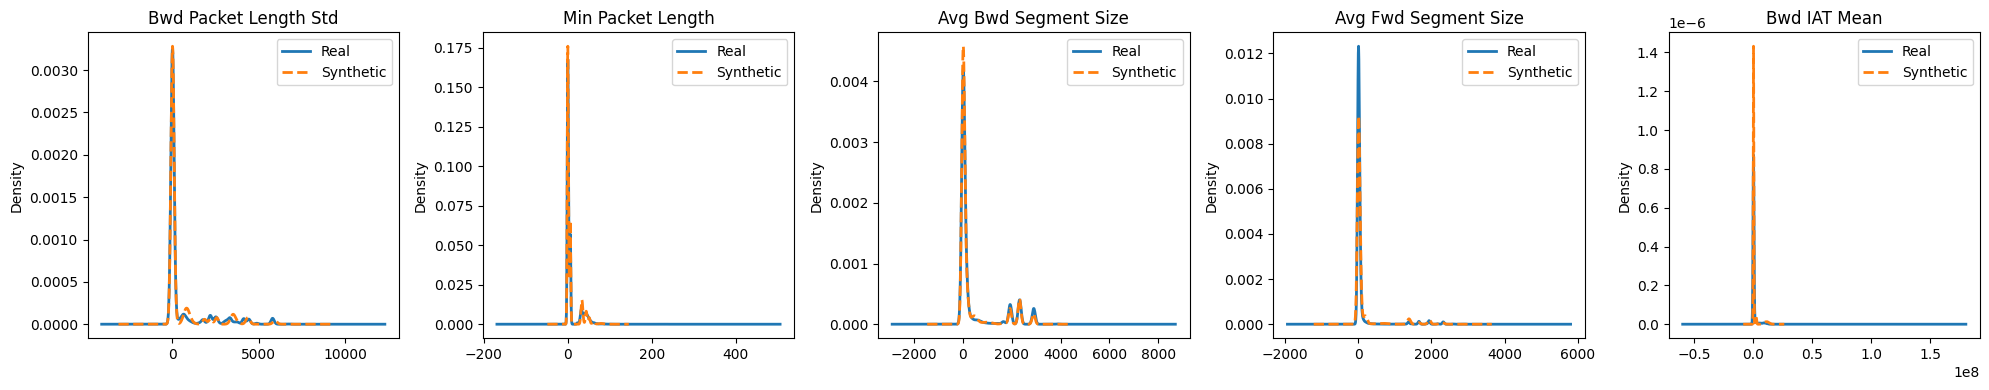

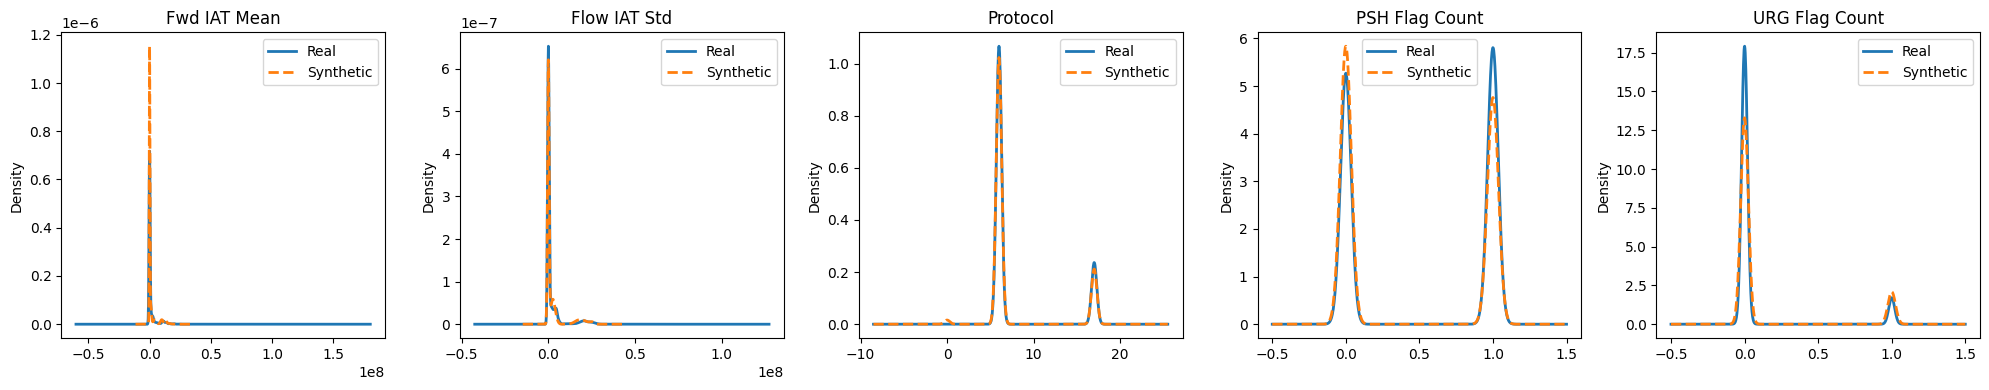

In [49]:
top_features = [
    'Fwd Packet Length Mean',
    'Flow Duration',
    'Bwd Packet Length Mean',
    'Flow Packets/s',
    'Flow Bytes/s',
    'Bwd Packet Length Std',
    'Min Packet Length',
    'Avg Bwd Segment Size',
    'Avg Fwd Segment Size',
    'Bwd IAT Mean',
    'Fwd IAT Mean',
    'Flow IAT Std',
    'Protocol',
    'PSH Flag Count',
    'URG Flag Count'
]

plot_all_kde(df, synth_df, features=top_features, cols_per_fig=5)